# Testing Age Window Sensitivity

## Motivation

The BBBM testing protocol currently tests people aged **65–80** (a 15-year window). But if
the true BBBM duration is much longer than the baseline assumption (Weibull scale 6.76,
mean ~6.3 yr), people may spend many years in the preclinical state **before** age 65 —
years when they could be identified and treated.

This notebook asks: **Does shifting the testing window earlier avert more DALYs, and does
this benefit depend on the assumed BBBM duration?**

### Design constraint

The testing window is always **15 years wide** (matching the current 65–80 protocol),
shifted earlier:

| Window | Age start | Age end |
|---|---|---|
| Earlier | 55 | 70 |
| Shifted | 60 | 75 |
| Current | 65 | 80 |

This isolates the effect of timing from the effect of coverage breadth.

### Hypothesis

- **Short BBBM duration** (scale ~4, mean ~3.8 yr): People enter BBBM in their early 60s
  and progress quickly. Earlier windows (55–70, 60–75) reach ages where few are yet in
  BBBM; benefit is modest.

- **Long BBBM duration** (scale ~15–25, mean ~14–23 yr): People may enter BBBM in their
  40s and remain preclinical for many years before 65. Shifting to 55–70 or 60–75 catches
  a substantial new cohort and gives treatment more downstream disease to prevent.

### Sweep design

- **Scale values**: 4 (short), 6.76 (default), 15 (long), 25 (very long)
  — all artifacts already exist from `bbbm_duration_consistent_rates.ipynb`, no MCMC needed.
- **Testing windows**: 55–70, 60–75, 65–80 (current); all 15 years wide
- **Scenarios**: `bbbm_testing` (ctrl) + `bbbm_testing_and_treatment` (treat)
- **Metrics**: DALYs averted (YLD+YLL), pipeline entrants, DALYs per entrant

Total: **4 × 3 × 2 = 24 simulations**, all with pre-computed consistent-rate artifacts.

In [2]:
import math
import os
import pickle
from contextlib import contextmanager

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import scipy
from loguru import logger
from tqdm.auto import tqdm
from vivarium import InteractiveContext

# Suppress vivarium's verbose INFO logging (uses loguru, not stdlib logging)
logger.disable("vivarium")

# Import modules we need to patch
import vivarium_csu_alzheimers.constants.data_values as dv_mod
import vivarium_csu_alzheimers.components.alzheimers as alz_mod
import vivarium_csu_alzheimers.data.consistent_rates as cr_mod
import vivarium_csu_alzheimers.components.testing as testing_mod

# --- Paths ---
SPEC_PATH = '../src/vivarium_csu_alzheimers/model_specifications/model_spec.yaml'
BASE_ARTIFACT = '../united_states_of_america.hdf'
ARTIFACT_DIR = '../artifacts_sweep'  # pre-computed artifacts from bbbm_duration_consistent_rates.ipynb
RESULTS_CACHE = os.path.join(ARTIFACT_DIR, 'age_sensitivity_cache.pkl')

# --- Simulation parameters ---
POPULATION_SIZE = 10_000
STEP_SIZE_DAYS = 182
STEP_SIZE_YEARS = STEP_SIZE_DAYS / 365.25
TARGET_YEAR = 2065  # slightly shorter than main notebook to keep runtime ~7-8 hrs

# --- Column names ---
DISEASE_COL = 'alzheimers_disease_and_other_dementias'
BBBM_STATE = 'alzheimers_blood_based_biomarker_state'
MCI_STATE = 'alzheimers_mild_cognitive_impairment_state'
DEMENTIA_STATE = 'alzheimers_disease_state'
TREATMENT_COL = 'treatment'

# --- Disability weights (mean across draws, consistent with tornado/bbbm notebooks) ---
DW_MCI = 0.021
DW_DEMENTIA = 0.258

# --- Weibull shape (fixed) ---
WEIBULL_SHAPE = 1.22
DEFAULT_SCALE = 6.76

# --- Pipeline states (any non-susceptible treatment state counts as 'entered pipeline') ---
PIPELINE_STATES = {
    'waiting_for_treatment', 'treatment_effect', 'waning_effect',
    'no_effect_after_treatment', 'no_effect_never_treated', 'positive_test',
}

## Sweep Parameters

Change these to adjust the sweep. Only scale values that already have pre-computed
artifacts in `../artifacts_sweep/` can be used (otherwise MCMC re-fitting is needed).

In [3]:
# Four representative BBBM duration assumptions.
# All these artifacts exist from bbbm_duration_consistent_rates.ipynb.
SWEEP_SCALES = [4, 6.76, 15, 25]

# Testing age window: start ages to sweep.
# The window is always WINDOW_WIDTH years wide, shifted earlier or later.
# Current protocol: 65–80. Earlier windows: 55–70, 60–75.
SWEEP_AGE_STARTS = [55, 60, 65]  # 65 is the current default
WINDOW_WIDTH = 15  # fixed window width (65-80 = 15 years)

# Scenarios to run for each (scale, age_start) combination
SCENARIOS = ['bbbm_testing', 'bbbm_testing_and_treatment']

# Summary of the sweep grid
print(f'Simulation target year: {TARGET_YEAR}')
print(f'Population size:        {POPULATION_SIZE:,}')
print(f'Window width (fixed):    {WINDOW_WIDTH} years')
print()
print('=== Testing windows ===')
for age_start in SWEEP_AGE_STARTS:
    age_end = age_start + WINDOW_WIDTH
    marker = ' <-- current' if age_start == 65 else ''
    print(f'  {age_start}–{age_end}{marker}')
print()
print('=== Sweep grid ===')
print(f'  Scale values:    {SWEEP_SCALES}')
print(f'  Age starts:      {SWEEP_AGE_STARTS}')
print(f'  Scenarios each:  {SCENARIOS}')
n_sims = len(SWEEP_SCALES) * len(SWEEP_AGE_STARTS) * len(SCENARIOS)
print(f'  Total sims:      {len(SWEEP_SCALES)} × {len(SWEEP_AGE_STARTS)} × {len(SCENARIOS)} = {n_sims}')
print()
print(f'{"Scale":>7s}  {"Mean duration (yr)":>18s}  {"Artifact"}')
print('-' * 65)
for s in SWEEP_SCALES:
    dist = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=s)
    if s == DEFAULT_SCALE:
        art_path = os.path.abspath(BASE_ARTIFACT)
    else:
        art_path = os.path.join(ARTIFACT_DIR, f'artifact_scale_{s}.hdf')
    exists = '✓' if os.path.exists(art_path) else '✗ MISSING'
    marker = ' <-- default' if s == DEFAULT_SCALE else ''
    print(f'{s:>7.2f}  {dist.mean():>18.2f}  {exists}{marker}')

Simulation target year: 2065
Population size:        10,000
Window width (fixed):    15 years

=== Testing windows ===
  55–70
  60–75
  65–80 <-- current

=== Sweep grid ===
  Scale values:    [4, 6.76, 15, 25]
  Age starts:      [55, 60, 65]
  Scenarios each:  ['bbbm_testing', 'bbbm_testing_and_treatment']
  Total sims:      4 × 3 × 2 = 24

  Scale  Mean duration (yr)  Artifact
-----------------------------------------------------------------
   4.00                3.75  ✓
   6.76                6.33  ✓ <-- default
  15.00               14.05  ✓
  25.00               23.42  ✓


In [4]:
# Build the artifact path map — reusing pre-computed artifacts, no MCMC needed
artifact_paths = {}
for scale in SWEEP_SCALES:
    if scale == DEFAULT_SCALE:
        artifact_paths[scale] = os.path.abspath(BASE_ARTIFACT)
    else:
        art_path = os.path.join(ARTIFACT_DIR, f'artifact_scale_{scale}.hdf')
        if not os.path.exists(art_path):
            raise FileNotFoundError(
                f'Artifact for scale={scale} not found at {art_path}.\n'
                f'Run bbbm_duration_consistent_rates.ipynb first to generate it.'
            )
        artifact_paths[scale] = os.path.abspath(art_path)

print('All artifacts confirmed present:')
for scale, path in artifact_paths.items():
    print(f'  scale={scale:>5.2f}: {path}')

All artifacts confirmed present:
  scale= 4.00: /home/abie/vivarium_csu_alzheimers/artifacts_sweep/artifact_scale_4.hdf
  scale= 6.76: /home/abie/vivarium_csu_alzheimers/united_states_of_america.hdf
  scale=15.00: /home/abie/vivarium_csu_alzheimers/artifacts_sweep/artifact_scale_15.hdf
  scale=25.00: /home/abie/vivarium_csu_alzheimers/artifacts_sweep/artifact_scale_25.hdf


## Patching Context Manager

Two things need to be patched per simulation run:

1. **BBBM duration** (`BBBM_AVG_DURATION` in `data_values`, `alzheimers`, and `consistent_rates`
   modules) — so the Weibull hazard uses the correct scale value.
2. **Testing age window** (`BBBM_AGE_MIN` in `data_values` and `testing` modules) — so the
   Testing component uses the swept age start instead of the hardcoded 65.

The `from X import Y` pattern in each module creates local name bindings, so we must patch
each module separately.

In [5]:
@contextmanager
def patch_for_simulation(scale, age_min, age_max):
    """
    Patch BBBM duration and testing age window for a single simulation run.
    Restores all original values on exit (even if an exception occurs).
    """
    new_dist = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale)
    new_avg = new_dist.mean()

    saved = {
        # Duration patches
        'dv_scale':    dv_mod.WEIBULL_SCALE,
        'dv_dist':     dv_mod.BBBM_HAZARD_DIST,
        'dv_avg':      dv_mod.BBBM_AVG_DURATION,
        'alz_dist':    alz_mod.BBBM_HAZARD_DIST,
        'alz_avg':     alz_mod.BBBM_AVG_DURATION,
        'cr_avg':      cr_mod.BBBM_AVG_DURATION,
        # Age patches
        'dv_age_min':   dv_mod.BBBM_AGE_MIN,
        'dv_age_max':   dv_mod.BBBM_AGE_MAX,
        'test_age_min': testing_mod.BBBM_AGE_MIN,
        'test_age_max': testing_mod.BBBM_AGE_MAX,
    }

    try:
        # Patch duration
        dv_mod.WEIBULL_SCALE      = scale
        dv_mod.BBBM_HAZARD_DIST   = new_dist
        dv_mod.BBBM_AVG_DURATION  = new_avg
        alz_mod.BBBM_HAZARD_DIST  = new_dist
        alz_mod.BBBM_AVG_DURATION = new_avg
        cr_mod.BBBM_AVG_DURATION  = new_avg
        # Patch age window
        dv_mod.BBBM_AGE_MIN        = age_min
        dv_mod.BBBM_AGE_MAX        = age_max
        testing_mod.BBBM_AGE_MIN   = age_min
        testing_mod.BBBM_AGE_MAX   = age_max
        yield
    finally:
        dv_mod.WEIBULL_SCALE       = saved['dv_scale']
        dv_mod.BBBM_HAZARD_DIST    = saved['dv_dist']
        dv_mod.BBBM_AVG_DURATION   = saved['dv_avg']
        alz_mod.BBBM_HAZARD_DIST   = saved['alz_dist']
        alz_mod.BBBM_AVG_DURATION  = saved['alz_avg']
        cr_mod.BBBM_AVG_DURATION   = saved['cr_avg']
        dv_mod.BBBM_AGE_MIN        = saved['dv_age_min']
        dv_mod.BBBM_AGE_MAX        = saved['dv_age_max']
        testing_mod.BBBM_AGE_MIN   = saved['test_age_min']
        testing_mod.BBBM_AGE_MAX   = saved['test_age_max']


# Smoke test: verify patching works correctly
print(f'Before: dv_mod.BBBM_AGE_MIN={dv_mod.BBBM_AGE_MIN}, BBBM_AGE_MAX={dv_mod.BBBM_AGE_MAX}')
print(f'Before: testing_mod.BBBM_AGE_MIN={testing_mod.BBBM_AGE_MIN}, BBBM_AGE_MAX={testing_mod.BBBM_AGE_MAX}')
with patch_for_simulation(scale=15, age_min=55, age_max=70):
    print(f'Inside: dv_mod.BBBM_AGE_MIN={dv_mod.BBBM_AGE_MIN}, BBBM_AGE_MAX={dv_mod.BBBM_AGE_MAX}')
    print(f'Inside: testing_mod.BBBM_AGE_MIN={testing_mod.BBBM_AGE_MIN}, BBBM_AGE_MAX={testing_mod.BBBM_AGE_MAX}')
    print(f'Inside: dv_mod.BBBM_AVG_DURATION={dv_mod.BBBM_AVG_DURATION:.2f} (window width: {dv_mod.BBBM_AGE_MAX - dv_mod.BBBM_AGE_MIN} yr)')
print(f'After:  dv_mod.BBBM_AGE_MIN={dv_mod.BBBM_AGE_MIN}, BBBM_AGE_MAX={dv_mod.BBBM_AGE_MAX}')
print('Patching verified ✓')

Before: dv_mod.BBBM_AGE_MIN=65, BBBM_AGE_MAX=80
Before: testing_mod.BBBM_AGE_MIN=65, BBBM_AGE_MAX=80
Inside: dv_mod.BBBM_AGE_MIN=55, BBBM_AGE_MAX=70
Inside: testing_mod.BBBM_AGE_MIN=55, BBBM_AGE_MAX=70
Inside: dv_mod.BBBM_AVG_DURATION=14.05 (window width: 15 yr)
After:  dv_mod.BBBM_AGE_MIN=65, BBBM_AGE_MAX=80
Patching verified ✓


## Simulation Function

In [6]:
def run_scenario(scenario, artifact_path, target_year=TARGET_YEAR, desc=None):
    """
    Run a single scenario, collecting person-steps by disease state and YLL.
    Must be called inside patch_for_simulation() context.

    Returns a dict of accumulated metrics over the simulation period.
    """
    sim = InteractiveContext(
        SPEC_PATH,
        configuration={
            'population': {'population_size': POPULATION_SIZE},
            'intervention': {'scenario': scenario},
            'input_data': {'artifact_path': artifact_path},
        }
    )

    target = pd.Timestamp(f'{target_year}-01-01')
    est_steps = max(1, math.ceil((target - sim.current_time).days / STEP_SIZE_DAYS))

    person_steps_bbbm = 0
    person_steps_mci = 0
    person_steps_dementia = 0
    total_alive_steps = 0
    yll = 0.0
    pipeline_entrants = set()
    alive_set = set()

    is_treatment = (scenario == 'bbbm_testing_and_treatment')
    label = desc or scenario.replace('bbbm_', '')

    with tqdm(total=est_steps, desc=label, unit='step', leave=False) as pbar:
        while sim.current_time < target:
            sim.step()
            pop = sim.get_population()
            alive = pop[pop['alive'] == 'alive']
            current_alive = set(alive.index)

            # Track deaths for YLL
            newly_dead = alive_set - current_alive
            for sid in newly_dead:
                if sid in pop.index:
                    yll += pop.loc[sid, 'years_of_life_lost']
            alive_set = current_alive

            # Accumulate person-steps
            disease_states = alive[DISEASE_COL]
            person_steps_bbbm     += (disease_states == BBBM_STATE).sum()
            person_steps_mci      += (disease_states == MCI_STATE).sum()
            person_steps_dementia += (disease_states == DEMENTIA_STATE).sum()
            total_alive_steps     += len(alive)

            # Track treatment pipeline entrants
            if is_treatment and TREATMENT_COL in alive.columns:
                in_pipeline = set(alive.index[alive[TREATMENT_COL].isin(PIPELINE_STATES)])
                pipeline_entrants |= in_pipeline

            pbar.update(1)

    return {
        'person_steps_bbbm':     person_steps_bbbm,
        'person_steps_mci':      person_steps_mci,
        'person_steps_dementia': person_steps_dementia,
        'total_alive_steps':     total_alive_steps,
        'yll':                   yll,
        'n_pipeline_entrants':   len(pipeline_entrants),
    }

In [7]:
def compute_metrics(ctrl_data, treat_data, scale, age_start):
    """Compute DALYs averted and related metrics from paired scenario runs."""
    mean_duration = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale).mean()
    age_end = age_start + WINDOW_WIDTH

    yld_ctrl  = (ctrl_data['person_steps_mci']      * DW_MCI +
                 ctrl_data['person_steps_dementia']  * DW_DEMENTIA) * STEP_SIZE_YEARS
    yld_treat = (treat_data['person_steps_mci']     * DW_MCI +
                 treat_data['person_steps_dementia'] * DW_DEMENTIA) * STEP_SIZE_YEARS

    yld_averted   = yld_ctrl - yld_treat
    yll_averted   = ctrl_data['yll'] - treat_data['yll']
    dalys_averted = yld_averted + yll_averted

    n_entrants = treat_data['n_pipeline_entrants']
    dalys_per_entrant = dalys_averted / n_entrants if n_entrants > 0 else 0.0

    return {
        'scale':             scale,
        'age_start':         age_start,
        'age_end':           age_end,
        'window':            f'{age_start}–{age_end}',
        'mean_duration':     mean_duration,
        'yld_averted':       yld_averted,
        'yll_averted':       yll_averted,
        'dalys_averted':     dalys_averted,
        'n_pipeline_entrants': n_entrants,
        'dalys_per_entrant': dalys_per_entrant,
        # Ctrl prevalences (for sanity check)
        'bbbm_prev': ctrl_data['person_steps_bbbm']     / ctrl_data['total_alive_steps'],
        'mci_prev':  ctrl_data['person_steps_mci']      / ctrl_data['total_alive_steps'],
        'dem_prev':  ctrl_data['person_steps_dementia'] / ctrl_data['total_alive_steps'],
    }

## Main Sweep Loop

Results are checkpointed after each (scale, age_start) pair so the notebook can be
restarted without losing completed work. To re-run everything from scratch, delete
`../artifacts_sweep/age_sensitivity_cache.pkl`.

In [8]:
# Load any previously completed results
cached = {}
if os.path.exists(RESULTS_CACHE):
    with open(RESULTS_CACHE, 'rb') as f:
        cached = pickle.load(f)
    print(f'Loaded {len(cached)} cached results: {sorted(cached.keys())}')
else:
    print('No cache found — starting fresh.')

results = []
n_total = len(SWEEP_SCALES) * len(SWEEP_AGE_STARTS)

with tqdm(total=n_total, desc='Sweep progress', unit='pair', position=0) as outer:
    for scale in SWEEP_SCALES:
        art_path = artifact_paths[scale]
        mean_dur = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale).mean()

        for age_start in SWEEP_AGE_STARTS:
            age_end = age_start + WINDOW_WIDTH
            key = (scale, age_start)
            outer.set_postfix_str(f'scale={scale}, window={age_start}–{age_end}')

            if key in cached:
                results.append(cached[key])
                outer.update(1)
                continue

            print(f'\n--- scale={scale} (mean {mean_dur:.1f} yr), window={age_start}–{age_end} ---')

            with patch_for_simulation(scale=scale, age_min=age_start, age_max=age_end):
                ctrl_label  = f'ctrl  ({age_start}–{age_end}, scale={scale})'
                treat_label = f'treat ({age_start}–{age_end}, scale={scale})'
                ctrl  = run_scenario('bbbm_testing',               art_path, desc=ctrl_label)
                treat = run_scenario('bbbm_testing_and_treatment', art_path, desc=treat_label)

            metrics = compute_metrics(ctrl, treat, scale, age_start)
            results.append(metrics)
            cached[key] = metrics

            # Checkpoint after each pair
            with open(RESULTS_CACHE, 'wb') as f:
                pickle.dump(cached, f)
            print(f'    DALYs averted: {metrics["dalys_averted"]:.1f}, '
                  f'pipeline entrants: {metrics["n_pipeline_entrants"]}')

            outer.update(1)

df = pd.DataFrame(results).sort_values(['scale', 'age_start']).reset_index(drop=True)
print(f'\nSweep complete: {len(df)} (scale, window) pairs evaluated.')

No cache found — starting fresh.


Sweep progress:   0%|          | 0/12 [00:00<?, ?pair/s]


--- scale=4 (mean 3.7 yr), window=55–70 ---


ctrl  (55–70, scale=4):   0%|          | 0/87 [00:00<?, ?step/s]

treat (55–70, scale=4):   0%|          | 0/87 [00:00<?, ?step/s]

...

treat (60–75, scale=25):   0%|          | 0/87 [00:00<?, ?step/s]

    DALYs averted: 968.6, pipeline entrants: 6766

--- scale=25 (mean 23.4 yr), window=65–80 ---


ctrl  (65–80, scale=25):   0%|          | 0/87 [00:00<?, ?step/s]

treat (65–80, scale=25):   0%|          | 0/87 [00:00<?, ?step/s]

    DALYs averted: 1136.4, pipeline entrants: 12064

Sweep complete: 12 (scale, window) pairs evaluated.


## Results

In [9]:
print(f'Population={POPULATION_SIZE:,}, simulation to {TARGET_YEAR}, window width={WINDOW_WIDTH} years')
print(f'DALYs averted = treatment vs testing-only (YLD + YLL)')
print()

hdr = (f'{"Scale":>7s}  {"Mean dur":>8s}  {"Window":>8s}  '
       f'{"BBBM prev":>9s}  {"YLD avt":>8s}  {"YLL avt":>8s}  '
       f'{"DALYs avt":>9s}  {"Pipeline":>8s}  {"DA/ent":>7s}')
print(hdr)
print('-' * len(hdr))

prev_scale = None
for _, row in df.iterrows():
    if row['scale'] != prev_scale and prev_scale is not None:
        print()
    prev_scale = row['scale']
    marker = ' *' if row['scale'] == DEFAULT_SCALE and row['age_start'] == 65 else ''
    print(f"{row['scale']:>7.2f}  {row['mean_duration']:>8.2f}  "
          f"{row['window']:>8s}  "
          f"{row['bbbm_prev']:>9.4f}  "
          f"{row['yld_averted']:>8.1f}  "
          f"{row['yll_averted']:>8.1f}  "
          f"{row['dalys_averted']:>9.1f}  "
          f"{row['n_pipeline_entrants']:>8.0f}  "
          f"{row['dalys_per_entrant']:>7.3f}{marker}")

# Highlight the incremental benefit of shifting the window earlier
print()
print('=== Incremental DALYs from shifting window earlier (vs current 65–80) ===')
ref_by_scale = df[df['age_start'] == 65].set_index('scale')['dalys_averted']
for _, row in df[df['age_start'] != 65].iterrows():
    ref = ref_by_scale.get(row['scale'], np.nan)
    delta = row['dalys_averted'] - ref
    pct = delta / ref * 100 if ref > 0 else np.nan
    print(f"  scale={row['scale']:>5.2f}, window={row['window']:>5s}: "
          f"{delta:>+7.1f} DALYs ({pct:>+.1f}%)")

Population=10,000, simulation to 2065, window width=15 years
DALYs averted = treatment vs testing-only (YLD + YLL)

  Scale  Mean dur    Window  BBBM prev   YLD avt   YLL avt  DALYs avt  Pipeline   DA/ent
----------------------------------------------------------------------------------------
   4.00      3.75     55–70     0.3317     122.9     346.3      469.2      1731    0.271
   4.00      3.75     60–75     0.3317     248.6     568.2      816.8      4006    0.204
   4.00      3.75     65–80     0.3317     365.2     659.2     1024.4      6441    0.159

   6.76      6.33     55–70     0.4788     178.9     690.5      869.4      2334    0.372
   6.76      6.33     60–75     0.4788     313.5     858.7     1172.2      4944    0.237
   6.76      6.33     65–80     0.4788     458.8    1065.3     1524.0      8126    0.188 *

  15.00     14.05     55–70     0.7010     183.5     565.8      749.2      2810    0.267
  15.00     14.05     60–75     0.7010     261.7     640.4      902.2      5389

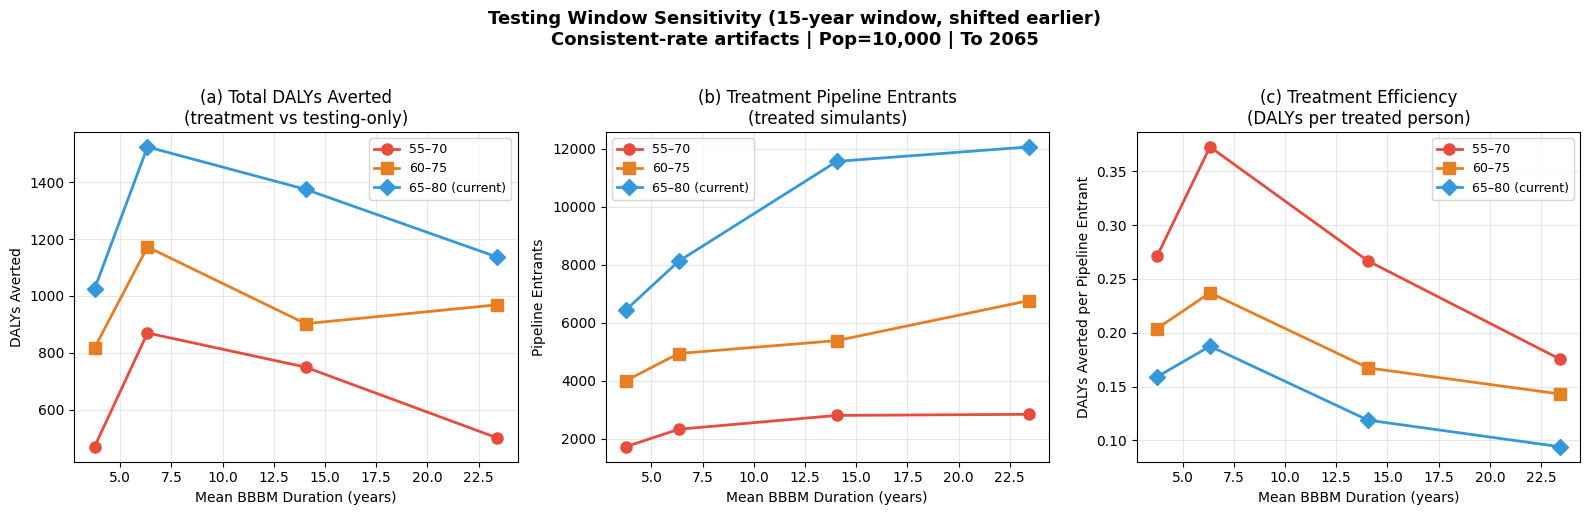

In [10]:
# --- Figure 1: DALYs averted, pipeline entrants, and efficiency vs BBBM duration ---
# One line per testing window (55–70, 60–75, 65–80), x-axis = mean BBBM duration
window_colors  = {55: '#e74c3c', 60: '#e67e22', 65: '#3498db'}
window_markers = {55: 'o',       60: 's',       65: 'D'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax_idx, (metric, ylabel, title) in enumerate([
    ('dalys_averted',    'DALYs Averted',                    '(a) Total DALYs Averted\n(treatment vs testing-only)'),
    ('n_pipeline_entrants', 'Pipeline Entrants',             '(b) Treatment Pipeline Entrants\n(treated simulants)'),
    ('dalys_per_entrant', 'DALYs Averted per Pipeline Entrant', '(c) Treatment Efficiency\n(DALYs per treated person)'),
]):
    ax = axes[ax_idx]
    for age_start in SWEEP_AGE_STARTS:
        age_end = age_start + WINDOW_WIDTH
        sub = df[df['age_start'] == age_start].sort_values('mean_duration')
        label = f'{age_start}–{age_end}'
        if age_start == 65:
            label += ' (current)'
        ax.plot(sub['mean_duration'], sub[metric],
                color=window_colors[age_start], marker=window_markers[age_start],
                markersize=8, linewidth=2, label=label)
    ax.set_xlabel('Mean BBBM Duration (years)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Testing Window Sensitivity ({WINDOW_WIDTH}-year window, shifted earlier)\n'
    f'Consistent-rate artifacts | Pop={POPULATION_SIZE:,} | To {TARGET_YEAR}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

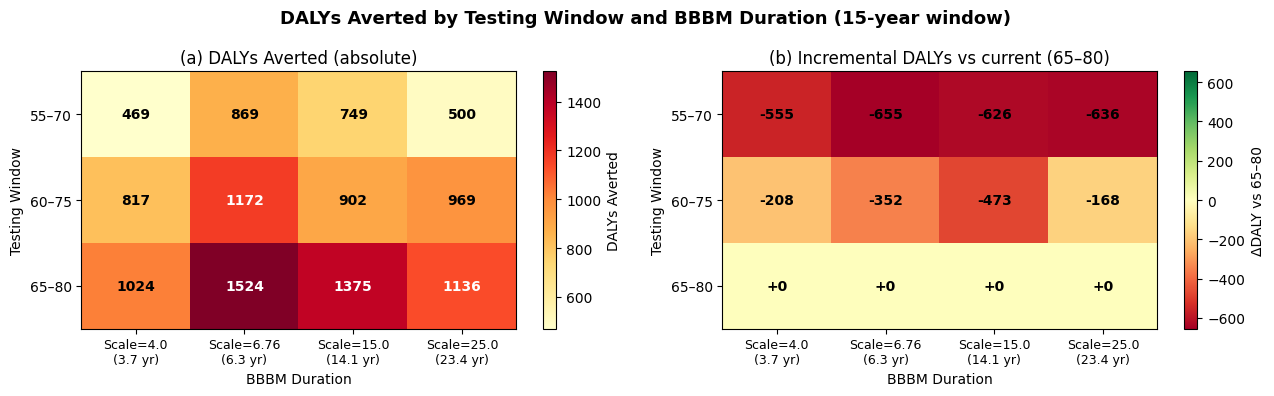


Incremental DALYs from shifting window earlier (vs 65–80):
scale       4.00        6.76        15.00       25.00
55–70 -555.178533 -654.608811 -625.603026 -636.376488
60–75 -207.672551 -351.813407 -472.682854 -167.777664
65–80    0.000000    0.000000    0.000000    0.000000


In [11]:
# --- Figure 2: Heatmaps — absolute and incremental DALYs ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pivot to (window × scale) matrix; use window string as index for display
pivot_dalys = df.pivot(index='age_start', columns='scale', values='dalys_averted')
pivot_delta = pivot_dalys.subtract(pivot_dalys.loc[65], axis='columns')

def format_scale_label(s):
    dur = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=s).mean()
    return f'Scale={s}\n({dur:.1f} yr)'

xlabels = [format_scale_label(s) for s in pivot_dalys.columns]
ylabels = [f'{a}–{a + WINDOW_WIDTH}' for a in pivot_dalys.index]

# (a) Absolute DALYs
ax = axes[0]
im = ax.imshow(pivot_dalys.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_yticks(range(len(ylabels)))
ax.set_yticklabels(ylabels, fontsize=10)
plt.colorbar(im, ax=ax, label='DALYs Averted')
for i in range(len(ylabels)):
    for j in range(len(xlabels)):
        val = pivot_dalys.values[i, j]
        ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if val > pivot_dalys.values.max() * 0.7 else 'black')
ax.set_title('(a) DALYs Averted (absolute)', fontsize=12)
ax.set_xlabel('BBBM Duration')
ax.set_ylabel('Testing Window')

# (b) Incremental DALYs vs current window (65–80)
ax = axes[1]
vmax = max(abs(pivot_delta.values.min()), abs(pivot_delta.values.max()))
im2 = ax.imshow(pivot_delta.values, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(xlabels)))
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_yticks(range(len(ylabels)))
ax.set_yticklabels(ylabels, fontsize=10)
plt.colorbar(im2, ax=ax, label='ΔDALY vs 65–80')
for i in range(len(ylabels)):
    for j in range(len(xlabels)):
        val = pivot_delta.values[i, j]
        ax.text(j, i, f'{val:+.0f}', ha='center', va='center',
                fontsize=10, fontweight='bold')
ax.set_title('(b) Incremental DALYs vs current (65–80)', fontsize=12)
ax.set_xlabel('BBBM Duration')
ax.set_ylabel('Testing Window')

fig.suptitle(f'DALYs Averted by Testing Window and BBBM Duration ({WINDOW_WIDTH}-year window)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nIncremental DALYs from shifting window earlier (vs 65–80):')
# Relabel index for display
display = pivot_delta.copy()
display.index = ylabels
print(display.to_string())

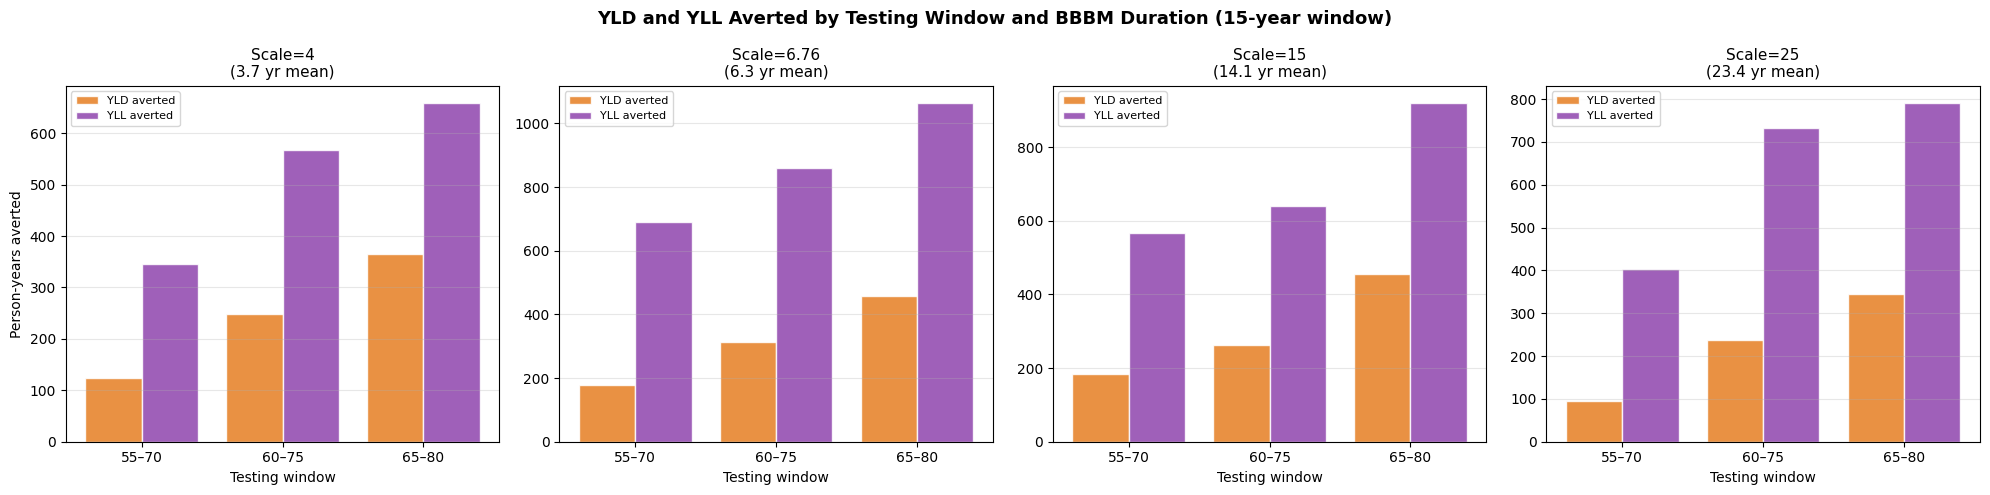

In [12]:
# --- Figure 3: YLD vs YLL breakdown by testing window and scale ---
fig, axes = plt.subplots(1, len(SWEEP_SCALES), figsize=(5 * len(SWEEP_SCALES), 5), sharey=False)

for ax, scale in zip(axes, SWEEP_SCALES):
    sub = df[df['scale'] == scale].sort_values('age_start')
    x = np.arange(len(sub))
    width = 0.4
    ax.bar(x - width/2, sub['yld_averted'], width, label='YLD averted',
           color='#e67e22', alpha=0.85, edgecolor='white')
    ax.bar(x + width/2, sub['yll_averted'], width, label='YLL averted',
           color='#8e44ad', alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(sub['window'], fontsize=10)
    ax.set_xlabel('Testing window')
    mean_dur = scipy.stats.weibull_min(WEIBULL_SHAPE, scale=scale).mean()
    ax.set_title(f'Scale={scale}\n({mean_dur:.1f} yr mean)', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('Person-years averted')

fig.suptitle(f'YLD and YLL Averted by Testing Window and BBBM Duration ({WINDOW_WIDTH}-year window)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretation

### What this analysis tests

The BBBM testing protocol currently identifies eligible individuals between ages 65 and 80
(a 15-year window). This notebook evaluates whether **shifting that window earlier** —
to 55–70 or 60–75 — averts more DALYs, and whether the benefit depends on the assumed
BBBM duration. Keeping window width fixed at 15 years ensures we are comparing window
*timing*, not window *breadth*.

### Expected interaction

For **short BBBM duration** (scale ~4, mean ~3.8 yr), most people enter BBBM in their early
60s and progress to MCI within a few years. Shifting to 55–70 reaches an age range where
few are yet in BBBM, so additional pipeline entrants are limited and the benefit is modest.

For **long BBBM duration** (scale ~15–25, mean ~14–23 yr), people may enter BBBM in their
40s–50s and remain preclinical for many years before reaching the current 65–80 window.
Shifting to 55–70 or 60–75:
1. Catches people who are already deep into their BBBM course before age 65
2. Treats them earlier, when more downstream disease (MCI + Dementia) remains to be prevented

This interaction — earlier testing helps more when BBBM is long — is the key result to
look for in the heatmap panel (b) and the lines in figure panel (a).

### One subtlety: the 65–80 window at different durations

Note that the 65–80 baseline is not held constant across scale values — each uses the
MCMC-refitted artifact for its scale. So the baseline (65–80) DALYs averted already
varies with scale (this is the main finding of `bbbm_duration_consistent_rates.ipynb`).
Figure panel (a) shows how window choice adds an additional layer of variation on top.

### Caveats

- **Testing rates unchanged**: Per-person test probabilities follow the same piecewise-linear
  ramp regardless of window. Shifting the window changes *who* is eligible but not the
  per-eligible-person testing rate.

- **Stochastic noise**: With 10,000 simulants, DALYs differences of a few hundred may
  be within noise. Interpret small Δ values in the heatmap cautiously.

- **Age-invariant treatment effect**: The model applies RR=0.528 uniformly. In reality,
  treatment efficacy may differ for 55-year-olds vs 75-year-olds.

- **Upper age cutoff matters too**: This notebook only shifts both endpoints together.
  Raising the upper cutoff (e.g., 65–90) is a separate and complementary question.